Sprint 9 – Bootstrap Analysis
Objective

Estimate reliable confidence intervals for customer metrics using Bootstrap Sampling.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import bootstrap

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

In [2]:
customers = pd.read_csv("../data/raw/customers.csv")

survey = pd.read_csv("../data/raw/survey_responses.csv")

In [3]:
df = customers.merge(
    survey,
    on="Customer_ID",
    how="inner"
)

df.head()

,Customer_ID,Age,Gender,City,Region,Education,Occupation,Income_Bracket,Customer_Segment,Survey_ID,Survey_Date,Brand_Awareness,Brand_Recall,Brand_Preference,Product_Quality,Service_Quality,Value_for_Money,Customer_Satisfaction,Recommend_Brand,Purchase_Intent
0,CUST00001,19,Female,Surat,West,Diploma,Government Employee,Medium,Regular,SURV00001,2025-08-17,Yes,ValueHub,NovaMart,4,3,4,4,9,High
1,CUST00002,55,Male,Ahmedabad,West,High School,Business Owner,Low,Regular,SURV00002,2025-09-05,Yes,ValueHub,UrbanCart,5,4,4,4,9,High
2,CUST00003,63,Female,Chennai,South,Bachelor,Business Owner,Medium,New,SURV00003,2025-05-11,Yes,MegaMart,UrbanCart,4,4,3,4,7,High
3,CUST00004,28,Female,Mumbai,West,Diploma,Government Employee,Low,Regular,SURV00004,2025-05-24,Yes,MegaMart,UrbanCart,3,4,4,4,7,High
4,CUST00005,23,Male,Surat,West,Bachelor,Healthcare Professional,Medium,Premium,SURV00005,2025-01-01,Yes,NovaMart,UrbanCart,2,1,1,1,3,Very Low


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Customer_ID            15000 non-null  str  
 1   Age                    15000 non-null  int64
 2   Gender                 15000 non-null  str  
 3   City                   15000 non-null  str  
 4   Region                 15000 non-null  str  
 5   Education              15000 non-null  str  
 6   Occupation             15000 non-null  str  
 7   Income_Bracket         15000 non-null  str  
 8   Customer_Segment       15000 non-null  str  
 9   Survey_ID              15000 non-null  str  
 10  Survey_Date            15000 non-null  str  
 11  Brand_Awareness        15000 non-null  str  
 12  Brand_Recall           15000 non-null  str  
 13  Brand_Preference       15000 non-null  str  
 14  Product_Quality        15000 non-null  int64
 15  Service_Quality        15000 non-null  int64
 1

What is Bootstrapping?

Bootstrap repeatedly samples the dataset with replacement to estimate population statistics such as the mean and confidence interval.

In [5]:
customer_satisfaction = df["Customer_Satisfaction"]

customer_satisfaction.head()

0    4
1    4
2    4
3    4
4    1
Name: Customer_Satisfaction, dtype: int64

In [6]:
bootstrap_means = []

for i in range(1000):

    sample = customer_satisfaction.sample(
        frac=1,
        replace=True
    )

    bootstrap_means.append(sample.mean())

In [7]:
print("Original Mean :", round(customer_satisfaction.mean(),2))

print("Bootstrap Mean :", round(np.mean(bootstrap_means),2))

Original Mean : 2.91
Bootstrap Mean : 2.91


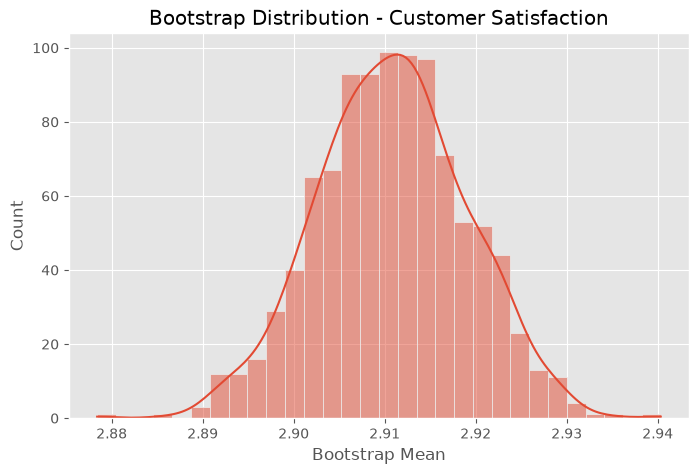

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(
    bootstrap_means,
    bins=30,
    kde=True
)

plt.title("Bootstrap Distribution - Customer Satisfaction")

plt.xlabel("Bootstrap Mean")

plt.show()

In [9]:
lower = np.percentile(
    bootstrap_means,
    2.5
)

upper = np.percentile(
    bootstrap_means,
    97.5
)

print("95% Confidence Interval")

print("Lower :",round(lower,2))

print("Upper :",round(upper,2))

95% Confidence Interval
Lower : 2.89
Upper : 2.93


Business Interpretation

The true average Customer Satisfaction is expected to lie within the calculated confidence interval with approximately 95% confidence.

In [10]:
product_quality = df["Product_Quality"]

pq_bootstrap = []

for i in range(1000):

    sample = product_quality.sample(
        frac=1,
        replace=True
    )

    pq_bootstrap.append(sample.mean())

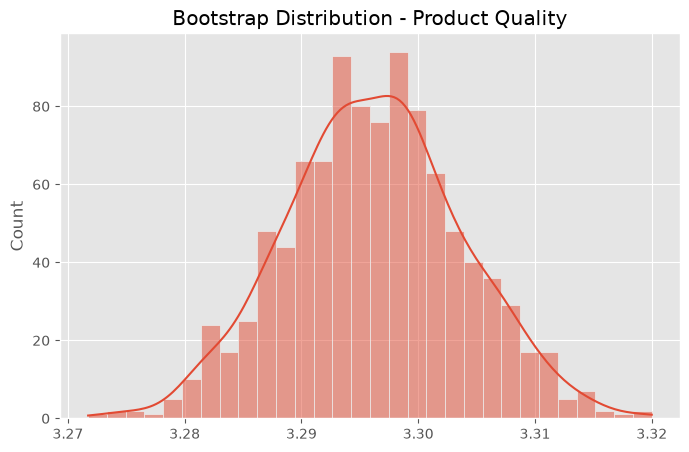

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(
    pq_bootstrap,
    bins=30,
    kde=True
)

plt.title("Bootstrap Distribution - Product Quality")

plt.show()

In [12]:
pq_lower = np.percentile(
    pq_bootstrap,
    2.5
)

pq_upper = np.percentile(
    pq_bootstrap,
    97.5
)

print("95% Confidence Interval")

print("Lower :",round(pq_lower,2))

print("Upper :",round(pq_upper,2))

95% Confidence Interval
Lower : 3.28
Upper : 3.31


In [13]:
service_quality = df["Service_Quality"]

sq_bootstrap = []

for i in range(1000):

    sample = service_quality.sample(
        frac=1,
        replace=True
    )

    sq_bootstrap.append(sample.mean())

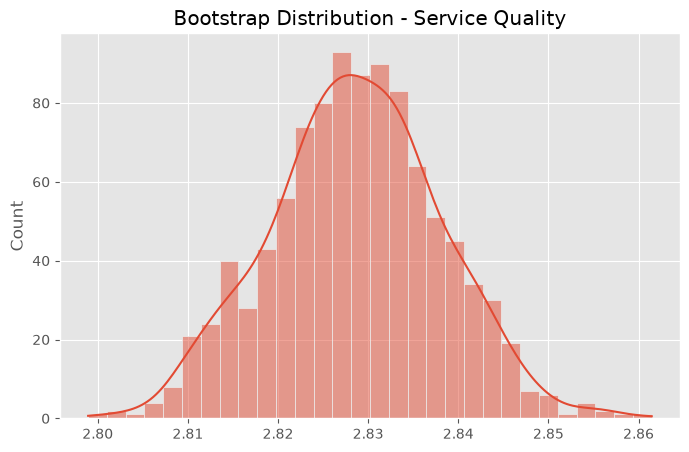

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(
    sq_bootstrap,
    bins=30,
    kde=True
)

plt.title("Bootstrap Distribution - Service Quality")

plt.show()

In [15]:
sq_lower = np.percentile(
    sq_bootstrap,
    2.5
)

sq_upper = np.percentile(
    sq_bootstrap,
    97.5
)

print("95% Confidence Interval")

print("Lower :",round(sq_lower,2))

print("Upper :",round(sq_upper,2))

95% Confidence Interval
Lower : 2.81
Upper : 2.85


In [16]:
summary = pd.DataFrame({

    "Metric":[
        "Customer Satisfaction",
        "Product Quality",
        "Service Quality"
    ],

    "Mean":[
        round(customer_satisfaction.mean(),2),
        round(product_quality.mean(),2),
        round(service_quality.mean(),2)
    ],

    "Lower CI":[
        round(lower,2),
        round(pq_lower,2),
        round(sq_lower,2)
    ],

    "Upper CI":[
        round(upper,2),
        round(pq_upper,2),
        round(sq_upper,2)
    ]

})

summary

,Metric,Mean,Lower CI,Upper CI
0,Customer Satisfaction,2.91,2.89,2.93
1,Product Quality,3.30,3.28,3.31
2,Service Quality,2.83,2.81,2.85


Business Insights
Bootstrap estimates closely match the original sample means.
Narrow confidence intervals indicate stable and reliable customer metrics.
Customer Satisfaction estimates are statistically reliable.
Product Quality and Service Quality can be monitored over time using Bootstrap confidence intervals.

Business Recommendations
Continue tracking Customer Satisfaction through periodic surveys.
Use Bootstrap confidence intervals in executive reports to communicate uncertainty.
Compare confidence intervals across customer segments and regions.
Use Bootstrap analysis to validate future survey-based decisions.

Sprint Summary

✔ Bootstrap Sampling

✔ Sampling with Replacement

✔ Bootstrap Mean

✔ Bootstrap Distribution

✔ Confidence Interval Estimation

✔ Business Interpretation

✔ Business Recommendations